In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = "/content/drive/MyDrive/StateNames.csv"
data = pd.read_csv(path, sep=',')
data = data.drop(['Id'], axis=1)

data

,Name,Year,Gender,State,Count
0,Mary,1910,F,AK,14
1,Annie,1910,F,AK,12
2,Anna,1910,F,AK,10
3,Margaret,1910,F,AK,8
4,Helen,1910,F,AK,7
...,...,...,...,...,...
5647421,Seth,2014,M,WY,5
5647422,Spencer,2014,M,WY,5
5647423,Tyce,2014,M,WY,5
5647424,Victor,2014,M,WY,5


Яка кількість спостережень ( samples , рядків)? Кількість ознак ( features , стовпців)?
Чи всі дані повні? Які типи стовпців?

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647426 entries, 0 to 5647425
Data columns (total 5 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   Name    object
 1   Year    int64 
 2   Gender  object
 3   State   object
 4   Count   int64 
dtypes: int64(2), object(3)
memory usage: 215.4+ MB


5 стовпців,

5647426 рядків,

всі дані повні,

dtypes: int64(3) object(3)

Яке ім’я зустрічається найчастіше? Скільки разів воно трапляється?

In [ ]:
data['Name'].value_counts()

Name
Leslie      7194
Lee         7125
James       7037
John        6865
Robert      6820
            ... 
Orpheus        1
Lavance        1
Medgar         1
Grayland       1
Marelie        1
Name: count, Length: 30274, dtype: int64

In [ ]:
data['Name'].value_counts()[0]

7194

In [ ]:
data['Name'].value_counts().index[0]

'Leslie'

Скільки різних імен зустрічається у таблиці? Яких імен — жіночих чи чоловічих —
більше?

In [ ]:
data["Gender"].value_counts()

Gender
F    3154009
M    2493417
Name: count, dtype: int64

різних имен зустрічаеться 30274
Жіночих імен зустрічається більше

Знайдіть топ-10 жіночих імен у штаті Нью-Йорк (NY) у 2010 році.

In [ ]:
fname=data[(data["Year"]==2010)&(data["Gender"]=="F")&(data["State"]=="NY")].groupby("Name").first()#.sort()#[-10:]
fname

,Year,Gender,State,Count
Name,,,,
Aaleyah,2010,F,NY,5
Aaliyah,2010,F,NY,236
Aanya,2010,F,NY,19
Abagail,2010,F,NY,11
Abbey,2010,F,NY,16
...,...,...,...,...
Zora,2010,F,NY,6
Zoya,2010,F,NY,11
Zunairah,2010,F,NY,5


In [ ]:
fname=data[(data["Year"]==2010)&(data["Gender"]=="F")&(data["State"]=="NY")]
fname.sort_values("Count", ascending=False)[:10]

,Name,Year,Gender,State,Count
3736880,Isabella,2010,F,NY,1521
3736881,Sophia,2010,F,NY,1382
3736882,Olivia,2010,F,NY,1184
3736883,Emma,2010,F,NY,1046
3736884,Ava,2010,F,NY,988
3736885,Madison,2010,F,NY,980
3736886,Emily,2010,F,NY,946
3736887,Mia,2010,F,NY,815
3736888,Abigail,2010,F,NY,784
3736889,Chloe,2010,F,NY,731


???  Виберіть дані з 2001 року. Знайдіть топ-10 імен по кожному штату за період 2001-
2014.

In [ ]:
a=data["State"].unique()
a

array(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA',
       'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME',
       'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM',
       'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'], dtype=object)

In [ ]:
data[(data["Year"]==2001)&(data[])]["Name"][:10]



10736      Madison
10737        Emily
10738       Hannah
10739       Ashley
10740      Abigail
10741    Elizabeth
10742         Emma
10743        Grace
10744     Victoria
10745        Haley
Name: Name, dtype: object

In [ ]:
data2001=data.groupby(["State"])[["State",'Name',"Count"]]#.agg()
data2001.head(100)

,State,Name,Count
0,AK,Mary,14
1,AK,Annie,12
2,AK,Anna,10
3,AK,Margaret,8
4,AK,Helen,7
...,...,...,...
5620607,WY,Ann,8
5620608,WY,Lucille,8
5620609,WY,Rose,8
5620610,WY,Edith,7


In [ ]:
data2001.sort_values("Count", ascending=False)[:10]

AttributeError: 'DataFrameGroupBy' object has no attribute 'sort_values'

In [ ]:
data2001=data.groupby(["State","Name"])[["Count"]].sum().sort_values("Count", ascending=False)[:10]#.nlargest(10,"Count")
data2001

Count
State Name           
NY    John     495099
      Robert   439554
      Michael  433757
CA    Michael  424585
PA    John     418876
CA    David    366353
PA    Robert   352256
CA    Robert   348971
NY    James    341356
      Joseph   340160

????  Знайдіть середню кількість кожного імені у всіх штатах з 2001 по 2014 рік.

In [ ]:
data["State"].value_counts()

State
CA    354213
TX    324133
NY    277809
IL    214609
FL    187567
PA    185715
OH    182203
MI    170856
GA    168983
NC    160853
NJ    142118
LA    140259
VA    136616
TN    130546
IN    129433
MO    129405
AL    126794
WA    114240
KY    111519
SC    110900
MA    110805
OK    109782
MS    108392
WI    108349
AZ    106323
MN    105888
MD    102900
CO     99475
AR     96237
KS     88337
IA     88131
UT     82570
OR     82162
CT     76922
WV     73789
NM     71648
NE     67611
ID     54129
DC     53328
HI     52069
ME     48167
SD     45009
ND     43858
MT     43501
NV     42244
RI     38327
NH     36968
DE     30423
VT     27734
WY     26914
AK     26663
Name: count, dtype: int64

In [ ]:
data2001_2014=data[(data["Year"]>=2001)&(data["Year"]<=2014)]
data2001_2014

,Name,Year,Gender,State,Count
10736,Madison,2001,F,AK,54
10737,Emily,2001,F,AK,47
10738,Hannah,2001,F,AK,46
10739,Ashley,2001,F,AK,40
10740,Abigail,2001,F,AK,39
...,...,...,...,...,...
5647421,Seth,2014,M,WY,5
5647422,Spencer,2014,M,WY,5
5647423,Tyce,2014,M,WY,5
5647424,Victor,2014,M,WY,5


In [ ]:
m=data2001_2014["Name"].value_counts()
m

Name
Riley       1414
Jordan      1379
Avery       1364
Taylor      1329
Peyton      1319
            ... 
Bethania       1
Harlym         1
Kijuan         1
Yohannes       1
Coalton        1
Name: count, Length: 18732, dtype: int64

In [ ]:
data2001_2014.groupby("State","Name")[["Count"]].mean()

ValueError: No axis named Name for object type DataFrame

In [ ]:
#c.groupby(['State'])['State', 'Name']#.agg({"Count": np.mean})

In [ ]:
data.describe()

,Year,Count
count,5.647426e+06,5.647426e+06
mean,1.972392e+03,5.292381e+01
std,2.957390e+01,1.808100e+02
min,1.910000e+03,5.000000e+00
25%,1.949000e+03,7.000000e+00
50%,1.977000e+03,1.300000e+01
75%,1.999000e+03,3.400000e+01
max,2.014000e+03,1.002300e+04


Відобразіть на графіку динаміку зміни популярності імені Donald за всі роки
(сумарно по всіх штатах).

In [ ]:
donald=data[data['Name']=="Donald"]
donald


,Name,Year,Gender,State,Count
13847,Donald,1917,M,AK,5
13891,Donald,1919,M,AK,5
13911,Donald,1920,M,AK,5
13921,Donald,1921,M,AK,11
13959,Donald,1922,M,AK,5
...,...,...,...,...,...
5643957,Donald,1992,M,WY,5
5644208,Donald,1994,M,WY,6
5644353,Donald,1995,M,WY,5
5644620,Donald,1997,M,WY,6


In [ ]:
donaldcount=donald['Year'].value_counts()
donaldcount

Year
1930    65
1933    64
1929    64
1931    63
1928    62
        ..
2010    36
2013    36
2014    35
2011    34
2012    34
Name: count, Length: 105, dtype: int64

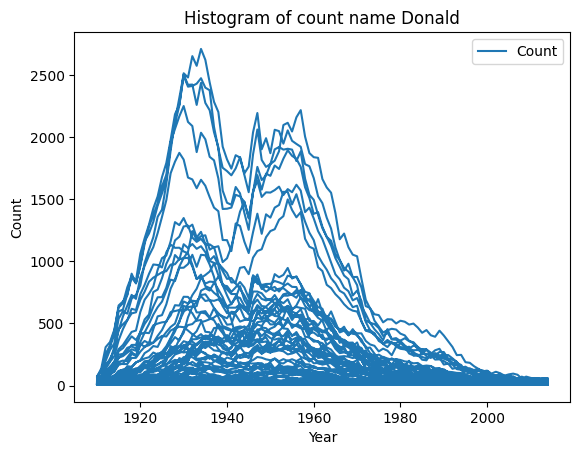

In [ ]:
donald.plot(x="Year",y="Count")#, bins=200)
plt.ylabel('Count')
plt.title('Histogram of count name Donald')
plt.xlabel('Year')
plt.show()

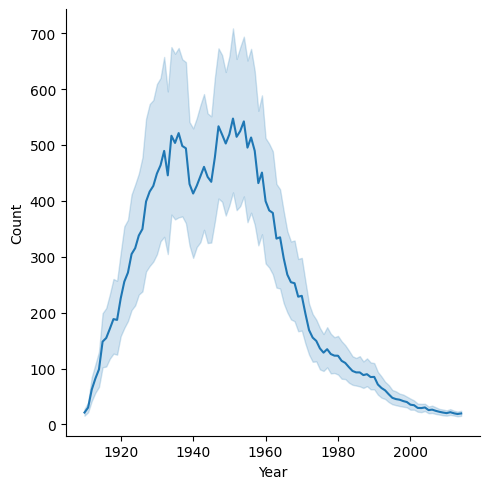

In [ ]:
sns.relplot(data=donald,x="Year",y="Count",kind="line")

Побудуйте інфографіку для топ-20 імен у 2013 році.

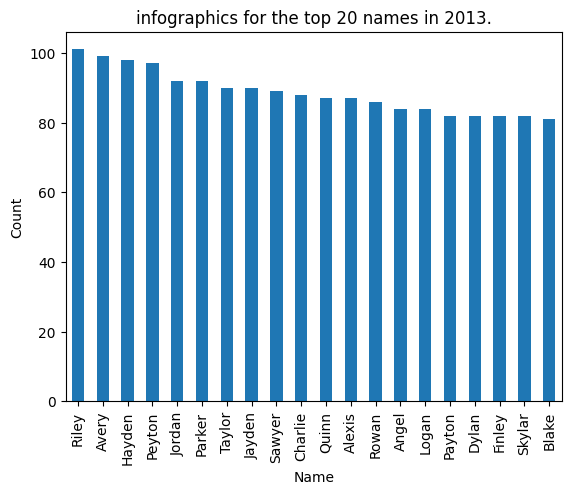

In [ ]:
data2013=data[(data['Year']==2013)]["Name"].value_counts().head(20).plot(kind='bar')
data2013
#data2013.sort_values("Count", ascending=False)[:20]    .value_counts().head(10).plot(kind='bar')
#plt.show()
plt.ylabel('Count')
plt.title('infographics for the top 20 names in 2013.')
plt.xlabel('Name')
plt.show()

In [ ]:
data2013=data[(data['Year']==2013)]["Name"].value_counts()
data2013

Name
Riley       101
Avery        99
Hayden       98
Peyton       97
Jordan       92
           ... 
Skyleigh      1
Teasia        1
Meleah        1
Mayumi        1
Lucus         1
Name: count, Length: 9553, dtype: int64

Побудуйте графік народжуваності чоловіків за роками в штаті Каліфорнія (CA).

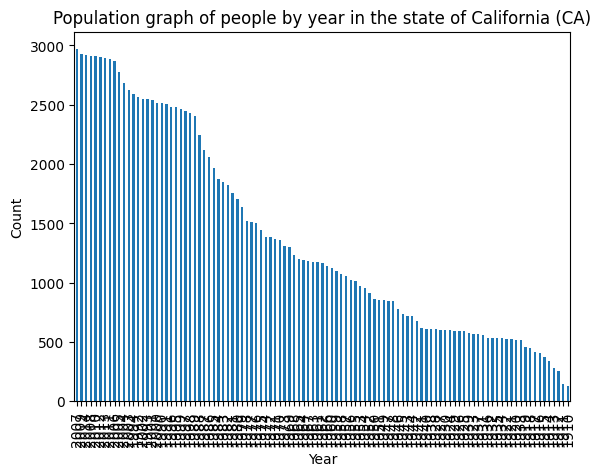

In [ ]:
data[(data["Gender"]=="M")&(data['State']=="CA")].value_counts("Year").plot(kind='bar')
plt.ylabel('Count')
plt.title('Population graph of people by year in the state of California (CA)')
plt.xlabel('Year')
plt.show()

In [ ]:
data[(data["Gender"]=="M")&(data['State']=="CA")].value_counts("Year")

Year
2007    2968
2009    2926
2014    2919
2008    2911
2010    2910
        ... 
1914     342
1913     280
1912     255
1911     142
1910     130
Name: count, Length: 105, dtype: int64

Відобразіть на графіку співвідношення між популярністю імені Helen по різних
штатах у 1910 та 2014 році. Обчисліть коефіцієнт кореляції

In [ ]:
helen=data[data['Name']=="Helen"]
helen

,Name,Year,Gender,State,Count
4,Helen,1910,F,AK,7
13,Helen,1911,F,AK,6
18,Helen,1912,F,AK,7
30,Helen,1913,F,AK,7
39,Helen,1914,F,AK,7
...,...,...,...,...,...
5626566,Helen,1961,F,WY,9
5627112,Helen,1964,F,WY,7
5627259,Helen,1965,F,WY,8
5628685,Helen,1975,F,WY,5


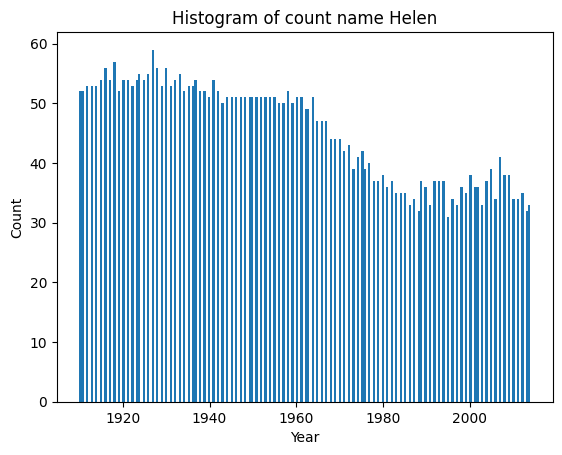

In [ ]:
helen["Year"].plot(kind='hist', bins=200)
plt.ylabel('Count')
plt.title('Histogram of count name Helen')
plt.xlabel('Year')
plt.show()

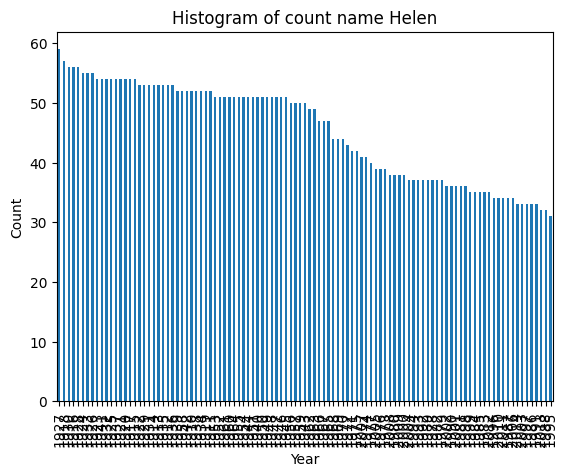

In [ ]:
helen.value_counts("Year") .plot(kind='bar')
plt.ylabel('Count')
plt.title('Histogram of count name Helen')
plt.xlabel('Year')
plt.show()

In [ ]:
helen1910=data[(data['Name']=="Helen")&(data['Year']==1910)]
helen1910

,Name,Year,Gender,State,Count
4,Helen,1910,F,AK,7
26716,Helen,1910,F,AL,76
153468,Helen,1910,F,AR,83
249698,Helen,1910,F,AZ,18
356018,Helen,1910,F,CA,239
710231,Helen,1910,F,CO,112
809706,Helen,1910,F,CT,170
886629,Helen,1910,F,DC,52
939957,Helen,1910,F,DE,37
970406,Helen,1910,F,FL,35


In [ ]:
helen2014=data[(data['Name']=="Helen")&(data['Year']==2014)]
helen2014#["State"]['Count']

#helen14=helen2014["State"]+helen2014['Count']

,Name,Year,Gender,State,Count
94547,Helen,2014,F,AL,13
309527,Helen,2014,F,AZ,6
561834,Helen,2014,F,CA,124
765023,Helen,2014,F,CO,14
852818,Helen,2014,F,CT,7
914654,Helen,2014,F,DC,8
1075004,Helen,2014,F,FL,37
1249315,Helen,2014,F,GA,31
1427734,Helen,2014,F,IA,6
1643341,Helen,2014,F,IL,27


In [ ]:
helen14=pd.pivot_table(helen2014, index='State', values='Count')
helen14

,Count
State,
AL,13
AZ,6
CA,124
CO,14
CT,7
DC,8
FL,37
GA,31
IA,6


In [ ]:
helen10=pd.pivot_table(helen1910, index='State', values='Count')
helen10

,Count
State,
AK,7.0
AL,76.0
AR,83.0
AZ,18.0
CA,239.0
CO,112.0
CT,170.0
DC,52.0
DE,37.0


In [ ]:
helen1910_2014=pd.pivot_table(helen, index='Year',columns='State', values='Count').iloc[[0, -1]]
helen1910_2014

State,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Year,,,,,,,,,,,,,,,,,,,,,
1910,7.0,76.0,83.0,18.0,239.0,112.0,170.0,52.0,37.0,35.0,...,60.0,90.0,189.0,36.0,185.0,34.0,156.0,252.0,124.0,13.0
2014,NaN,13.0,NaN,6.0,124.0,14.0,7.0,8.0,NaN,37.0,...,NaN,13.0,94.0,7.0,33.0,NaN,17.0,14.0,NaN,NaN


<Axes: xlabel='Year'>

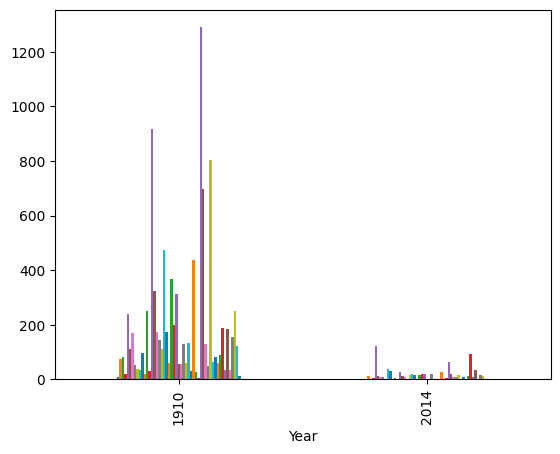

In [ ]:
helen1910_2014.plot(kind='bar',legend=False)#,x='State', y='Count', legend=False)

In [ ]:
hel=pd.pivot_table(helen, index='State',columns="Year", values='Count')
hel

Year,1910,1911,1912,1913,1914,1915,1916,1917,1918,1919,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
State,,,,,,,,,,,,,,,,,,,,,
AK,7.0,6.0,7.0,7.0,7.0,12.0,12.0,10.0,10.0,11.0,...,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN
AL,76.0,70.0,128.0,128.0,172.0,188.0,225.0,246.0,284.0,346.0,...,14.0,19.0,7.0,12.0,15.0,14.0,15.0,11.0,9.0,13.0
AR,83.0,100.0,144.0,135.0,174.0,243.0,248.0,319.0,319.0,392.0,...,7.0,6.0,7.0,8.0,8.0,NaN,6.0,5.0,7.0,NaN
AZ,18.0,19.0,30.0,26.0,41.0,57.0,64.0,74.0,67.0,92.0,...,29.0,24.0,15.0,13.0,12.0,10.0,12.0,12.0,8.0,6.0
CA,239.0,209.0,321.0,376.0,471.0,602.0,584.0,613.0,641.0,657.0,...,154.0,188.0,169.0,158.0,137.0,136.0,107.0,132.0,128.0,124.0
CO,112.0,109.0,135.0,157.0,173.0,237.0,280.0,281.0,297.0,287.0,...,20.0,16.0,18.0,14.0,9.0,6.0,12.0,14.0,10.0,14.0
CT,170.0,223.0,285.0,382.0,489.0,619.0,698.0,792.0,833.0,728.0,...,7.0,6.0,9.0,10.0,6.0,9.0,7.0,NaN,NaN,7.0
DC,52.0,44.0,59.0,78.0,93.0,102.0,106.0,121.0,137.0,129.0,...,6.0,5.0,NaN,9.0,7.0,5.0,8.0,7.0,NaN,8.0
DE,37.0,37.0,37.0,59.0,62.0,71.0,73.0,93.0,90.0,103.0,...,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
pd.Series.corr(hel[1910],hel[2014])

0.24149223430966782

In [ ]:
inflation_unemploy.plot(kind='scatter', x='unemployment_rate', y='cpi')
plt.show()


# Create a line plot of the number of avocados sold by date
nb_sold_by_date.plot(kind="line")

# Show the plot
plt.show()



# Scatter plot of avg_price vs. nb_sold with title
avocados.plot(x="nb_sold", y="avg_price", kind="scatter", title="Number of avocados sold vs. average price")

# Show the plot
plt.show()

# Check each column for missing values
print(avocados_2016.isna().any())

# Remove rows with missing values
avocados_complete = avocados_2016.dropna()

# Check if any columns contain missing values
print(avocados_complete.isna().any())

In [ ]:
hel.columns

Index([1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919,
       ...
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014],
      dtype='int64', name='Year', length=105)

In [ ]:
hel[1910],hel[2014]

(State
 AK       7.0
 AL      76.0
 AR      83.0
 AZ      18.0
 CA     239.0
 CO     112.0
 CT     170.0
 DC      52.0
 DE      37.0
 FL      35.0
 GA      98.0
 HI      20.0
 IA     249.0
 ID      30.0
 IL     917.0
 IN     324.0
 KS     172.0
 KY     146.0
 LA     113.0
 MA     473.0
 MD     174.0
 ME      60.0
 MI     368.0
 MN     201.0
 MO     313.0
 MS      57.0
 MT      58.0
 NC     129.0
 ND      59.0
 NE     134.0
 NH      30.0
 NJ     438.0
 NM      26.0
 NV       5.0
 NY    1290.0
 OH     698.0
 OK     131.0
 OR      48.0
 PA     804.5
 RI      63.0
 SC      83.0
 SD      60.0
 TN      90.0
 TX     189.0
 UT      36.0
 VA     185.0
 VT      34.0
 WA     156.0
 WI     252.0
 WV     124.0
 WY      13.0
 Name: 1910, dtype: float64,
 State
 AK      NaN
 AL     13.0
 AR      NaN
 AZ      6.0
 CA    124.0
 CO     14.0
 CT      7.0
 DC      8.0
 DE      NaN
 FL     37.0
 GA     31.0
 HI      NaN
 IA      6.0
 ID      NaN
 IL     27.0
 IN     11.0
 KS      9.0
 KY      NaN
 LA     1